# Trực quan kết quả GAM

> Notebook này **không train lại** — nạp thẳng model đã lưu ở `model/GAM/*.joblib` và
> dự đoán ở `evaluation/pred_gam.parquet`. Chạy `Run All` ~2 phút.

## GAM là gì trong bối cảnh này

```
Hồi quy tuyến tính:  y = b₀ + b₁·x₁ + b₂·x₂ + ...      ← mỗi biến 1 đường THẲNG
GAM:                 y = b₀ + f₁(x₁) + f₂(x₂) + ...    ← mỗi biến 1 đường CONG riêng
Boosting tree:       y = f(x₁, x₂, ...)                 ← học cả TƯƠNG TÁC, hộp đen
```

Mỗi `fᵢ` là một **spline** ghép từ 12 đoạn đa thức trơn (`n_splines=12`), phạt độ gấp khúc bằng
`λ` để chống overfit. Điểm mấu chốt: **các hàm CỘNG dồn, không nhân** — GAM học được *"giá tăng
theo quãng đường rồi bão hoà"* nhưng **không** học được *"quãng đường dài **và** giờ cao điểm thì
tăng gấp bội"*.

## Kiến trúc đang dùng

| Model | Term | Feature |
|---|---|---|
| Giá cơ bản | 14 = 10 `s()` + 4 `f()` | `B_NUM` + 4 categorical |
| Giá trực tiếp | 14 = 10 `s()` + 4 `f()` | `D_NUM` + 4 categorical |
| Hệ số nhân | 11 = 7 `s()` + 4 `f()` | `M_NUM` + 4 categorical |

Train **riêng từng tháng** (01/02/03), target `log(y)`, cùng feature contract và giao thức chia
dữ liệu với nhóm boosting tree.

## Ba câu hỏi notebook này trả lời

| # | Câu hỏi | Hình |
|---|---|---|
| 1 | GAM đứng đâu so với 3 model cây? | `GA1` |
| 2 | GAM học ra hình dạng quan hệ gì? *(thứ cây không cho trực tiếp)* | `GA2`, `GA3`, `GA4` |
| 3 | **Vì sao GAM thua rõ ở hệ số nhân?** | `GA5`, `GA6` |

In [1]:
import warnings, joblib
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
GAMDIR = Path("../GAM")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

CAT = ["service_name", "pickup_location_name", "dropoff_location_name", "weather_main"]
B_NUM = ["quote_distance", "quote_duration", "gio_vn", "latest_observed_base",
         "history_60m_price_mean", "history_60m_price_std",
         "history_60m_price_slope_per_minute", "latest_observed_quote_distance",
         "latest_observed_quote_duration", "actual_observation_age_minutes"]
M_NUM = ["pricing_market_imbalance_5m_lag", "pricing_demand_index_5m_lag",
         "pricing_supply_index_5m_lag", "pricing_quote_count_5m_lag",
         "latest_observed_multiplier", "gio_vn", "actual_observation_age_minutes"]

enc = joblib.load(GAMDIR / "encoder.joblib")
gam_base = joblib.load(GAMDIR / "gia_co_ban.joblib")
gam_heso = joblib.load(GAMDIR / "heso.joblib")
gam_gia = joblib.load(GAMDIR / "gia.joblib")
THANG = sorted(gam_base)

print("Da nap model GAM (dict theo thang):", THANG)
for ten, d in [("gia_co_ban", gam_base), ("heso", gam_heso), ("gia", gam_gia)]:
    g0 = d[THANG[-1]]
    print(f"  {ten:12s} {len(g0.terms)-1:2d} term | "
          f"pseudo-R2 {g0.statistics_['pseudo_r2']['explained_deviance']:.4f}")

Da nap model GAM (dict theo thang): ['2026-01', '2026-02', '2026-03']
  gia_co_ban   14 term | pseudo-R2 0.6910
  heso         11 term | pseudo-R2 0.9526
  gia          14 term | pseudo-R2 0.7274


## 1. GAM đứng đâu so với 3 model cây

In [2]:
gam = pd.read_parquet("pred_gam.parquet")
gam = gam[gam.split == "test"].reset_index(drop=True)
uq = pd.read_parquet("uq_pred_test.parquet")
assert np.allclose(gam.gia_that.values, uq.gia_that.values), "2 file khong khop hang!"
print(f"Tap test: {len(gam):,} chuyen — 2 file khop hang.")


def do(p, t):
    p, t = np.asarray(p, float), np.asarray(t, float)
    return (np.abs(p-t).mean(), (np.abs(p-t)/t).mean(),
            1 - ((p-t)**2).sum()/((t-t.mean())**2).sum())


pg = pd.read_parquet("pred_gia.parquet",
                     columns=["split", "algo", "pred", "target_shown_price"])
pg = pg[pg.split == "test"]

rows = []
for ten, p, t in [("Giá cơ bản", gam.base_pred, uq.base_that),
                  ("Hệ số nhân", gam.heso_pred, uq.heso_that),
                  ("Hybrid (A×B)", gam.hybrid_pred, gam.gia_that),
                  ("Giá trực tiếp", gam.truc_tiep_pred, gam.gia_that)]:
    mae, mape, r2 = do(p, t)
    rows.append({"Nhánh": ten, "Model": "GAM", "MAE": mae, "MAPE": mape, "R²": r2})
for ten, p, t in [("Giá cơ bản", uq.base_pred, uq.base_that),
                  ("Hệ số nhân", uq.heso_pred, uq.heso_that),
                  ("Hybrid (A×B)", uq.hybrid_pred, uq.gia_that)]:
    mae, mape, r2 = do(p, t)
    rows.append({"Nhánh": ten, "Model": "HistGB", "MAE": mae, "MAPE": mape, "R²": r2})
best = pg[pg.algo == "XGBoost"]
mae, mape, r2 = do(best.pred, best.target_shown_price)
rows.append({"Nhánh": "Giá trực tiếp", "Model": "XGBoost", "MAE": mae, "MAPE": mape, "R²": r2})

B = pd.DataFrame(rows)
piv = B.pivot(index="Nhánh", columns="Model", values="MAE").reindex(
    ["Giá cơ bản", "Hệ số nhân", "Hybrid (A×B)", "Giá trực tiếp"])
print("\nMAE theo nhanh:")
display(piv.round(4))
print("\nChi tiet:")
display(B.assign(MAE=lambda x: x.MAE.round(4), MAPE=lambda x: (x.MAPE*100).round(2),
                 **{"R²": lambda x: x["R²"].round(4)}))

Tap test: 864,360 chuyen — 2 file khop hang.



MAE theo nhanh:


Model,GAM,HistGB,XGBoost
Nhánh,,,
Giá cơ bản,15098.7308,15030.2181,NaN
Hệ số nhân,0.0303,0.0232,NaN
Hybrid (A×B),18241.7162,18044.6671,NaN
Giá trực tiếp,19172.5255,NaN,18806.7164



Chi tiet:


,Nhánh,Model,MAE,MAPE,R²
0,Giá cơ bản,GAM,15098.7308,14.78,0.6599
1,Hệ số nhân,GAM,0.0303,2.48,0.9400
2,Hybrid (A×B),GAM,18241.7162,15.02,0.7286
3,Giá trực tiếp,GAM,19172.5255,15.70,0.6977
4,Giá cơ bản,HistGB,15030.2181,14.58,0.6564
5,Hệ số nhân,HistGB,0.0232,1.90,0.9609
6,Hybrid (A×B),HistGB,18044.6671,14.74,0.7299
7,Giá trực tiếp,XGBoost,18806.7164,15.34,0.7056


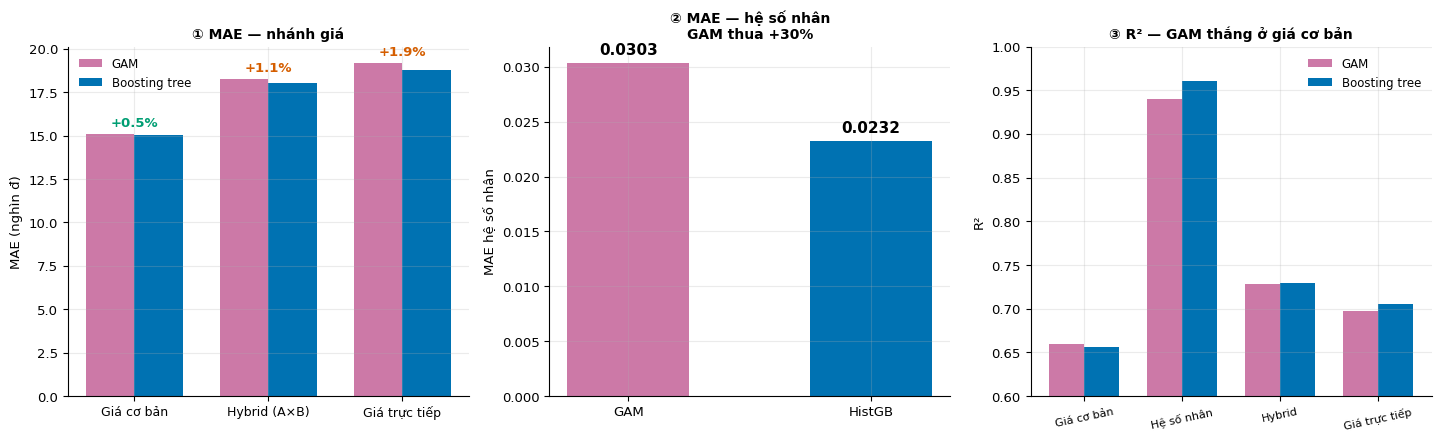

GAM ngang cay o GIA CO BAN (R2 con cao hon), thua ro o HE SO NHAN.
=> Gia co ban: quan he CONG DON thuan.
   He so nhan: co TUONG TAC that su -> Phan 3 kiem chung.


In [3]:
# ═════════ HINH GA1 — GAM vs cay ═════════
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.5))

nhanh = ["Giá cơ bản", "Hybrid (A×B)", "Giá trực tiếp"]
g_ = [B[(B.Nhánh == n) & (B.Model == "GAM")].MAE.iloc[0] for n in nhanh]
c_ = [B[(B.Nhánh == n) & (B.Model != "GAM")].MAE.iloc[0] for n in nhanh]
x = np.arange(len(nhanh)); w = .36
ax[0].bar(x-w/2, np.array(g_)/1000, w, color=PURPLE, label="GAM")
ax[0].bar(x+w/2, np.array(c_)/1000, w, color=BLUE, label="Boosting tree")
for i, (a_, b_) in enumerate(zip(g_, c_)):
    ax[0].text(i, max(a_, b_)/1000+0.45, f"{(a_/b_-1)*100:+.1f}%", ha="center",
               fontsize=9.5, fontweight="bold",
               color=RED if a_ > b_*1.005 else GREEN)
ax[0].set_xticks(x); ax[0].set_xticklabels(nhanh, fontsize=9)
ax[0].set_ylabel("MAE (nghìn đ)"); ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① MAE — nhánh giá", fontweight="bold", fontsize=10)

mg = B[(B.Nhánh == "Hệ số nhân") & (B.Model == "GAM")]
mh = B[(B.Nhánh == "Hệ số nhân") & (B.Model == "HistGB")]
b2 = ax[1].bar(["GAM", "HistGB"], [mg.MAE.iloc[0], mh.MAE.iloc[0]],
               color=[PURPLE, BLUE], width=.5)
for bb, v in zip(b2, [mg.MAE.iloc[0], mh.MAE.iloc[0]]):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+.0008, f"{v:.4f}", ha="center",
               fontsize=11, fontweight="bold")
ax[1].set_ylabel("MAE hệ số nhân")
ax[1].set_title(f"② MAE — hệ số nhân\nGAM thua {(mg.MAE.iloc[0]/mh.MAE.iloc[0]-1)*100:+.0f}%",
                fontweight="bold", fontsize=10)

nh4 = ["Giá cơ bản", "Hệ số nhân", "Hybrid (A×B)", "Giá trực tiếp"]
gr = [B[(B.Nhánh == n) & (B.Model == "GAM")]["R²"].iloc[0] for n in nh4]
cr = [B[(B.Nhánh == n) & (B.Model != "GAM")]["R²"].iloc[0] for n in nh4]
x4 = np.arange(4)
ax[2].bar(x4-w/2, gr, w, color=PURPLE, label="GAM")
ax[2].bar(x4+w/2, cr, w, color=BLUE, label="Boosting tree")
ax[2].set_xticks(x4)
ax[2].set_xticklabels([n.replace(" (A×B)", "") for n in nh4], fontsize=8, rotation=12)
ax[2].set_ylabel("R²"); ax[2].set_ylim(0.6, 1.0)
ax[2].legend(frameon=False, fontsize=8.5)
ax[2].set_title("③ R² — GAM thắng ở giá cơ bản", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "GA1_gam_vs_cay.png"); plt.show()

print("=" * 62)
print("GAM ngang cay o GIA CO BAN (R2 con cao hon), thua ro o HE SO NHAN.")
print("=> Gia co ban: quan he CONG DON thuan.")
print("   He so nhan: co TUONG TAC that su -> Phan 3 kiem chung.")
print("=" * 62)

## 2. Đường cong GAM học được — thứ boosting tree không cho trực tiếp

Đây là giá trị riêng của GAM: vẽ được **chính xác** hàm `f(feature)` mà model học, kèm khoảng tin
cậy 95%. Với cây phải xấp xỉ bằng SHAP hoặc permutation importance.

Trục tung là **đóng góp vào `log(y)`** — đọc là *"feature này đẩy giá lên/xuống bao nhiêu %"*.

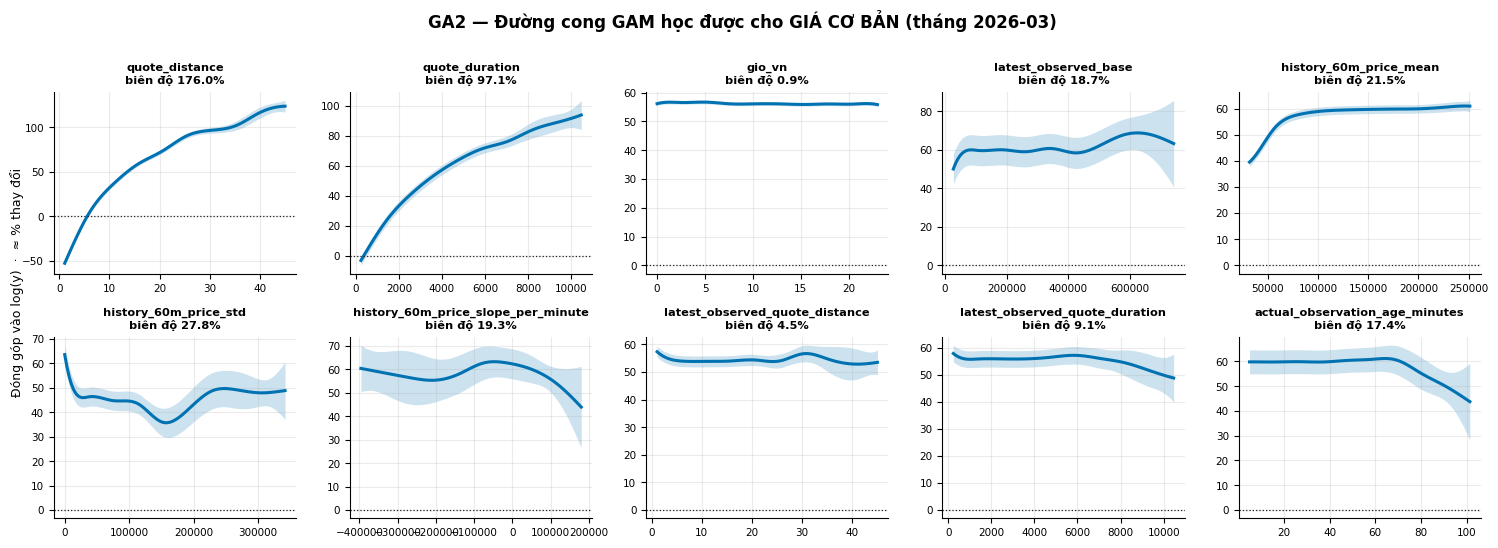

Bien do anh huong tung feature — GIA CO BAN:


,Feature,Biên độ (%)
0,quote_distance,175.97
1,quote_duration,97.06
2,history_60m_price_std,27.81
3,history_60m_price_mean,21.46
4,history_60m_price_slope_per_minute,19.33
5,latest_observed_base,18.73
6,actual_observation_age_minutes,17.41
7,latest_observed_quote_duration,9.09
8,latest_observed_quote_distance,4.48
9,gio_vn,0.88


In [4]:
def ve_duong_cong(gam_obj, ten_feat, tieu_de, ten_file, ncol=5):
    n = len(ten_feat)
    nrow = int(np.ceil(n/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.05*ncol, 2.7*nrow))
    axes = np.atleast_1d(axes).ravel()
    for i, name in enumerate(ten_feat):
        a = axes[i]
        XX = gam_obj.generate_X_grid(term=i)
        pd_, ci = gam_obj.partial_dependence(term=i, X=XX, width=0.95)
        xv = XX[:, i]
        a.plot(xv, pd_*100, color=BLUE, lw=2.2)
        a.fill_between(xv, ci[:, 0]*100, ci[:, 1]*100, alpha=.20, color=BLUE, lw=0)
        a.axhline(0, color=INK, lw=.9, ls=":")
        bien_do = (pd_.max()-pd_.min())*100
        a.set_title(f"{name}\nbiên độ {bien_do:.1f}%", fontsize=8.2, fontweight="bold")
        a.tick_params(labelsize=7.5)
    for j in range(n, len(axes)):
        axes[j].axis("off")
    fig.supylabel("Đóng góp vào log(y)  ·  ≈ % thay đổi", fontsize=9)
    fig.suptitle(tieu_de, fontweight="bold", fontsize=12, y=1.005)
    plt.tight_layout(); plt.savefig(HINH / ten_file); plt.show()

    bd = []
    for i, name in enumerate(ten_feat):
        XX = gam_obj.generate_X_grid(term=i)
        p_, _ = gam_obj.partial_dependence(term=i, X=XX, width=0.95)
        bd.append({"Feature": name, "Biên độ (%)": round((p_.max()-p_.min())*100, 2)})
    return pd.DataFrame(bd).sort_values("Biên độ (%)", ascending=False)


# ═════════ HINH GA2 — duong cong GIA CO BAN ═════════
bd_base = ve_duong_cong(gam_base[THANG[-1]], B_NUM,
                        f"GA2 — Đường cong GAM học được cho GIÁ CƠ BẢN (tháng {THANG[-1]})",
                        "GA2_duong_cong_gia_co_ban.png")
print("Bien do anh huong tung feature — GIA CO BAN:")
display(bd_base.reset_index(drop=True))

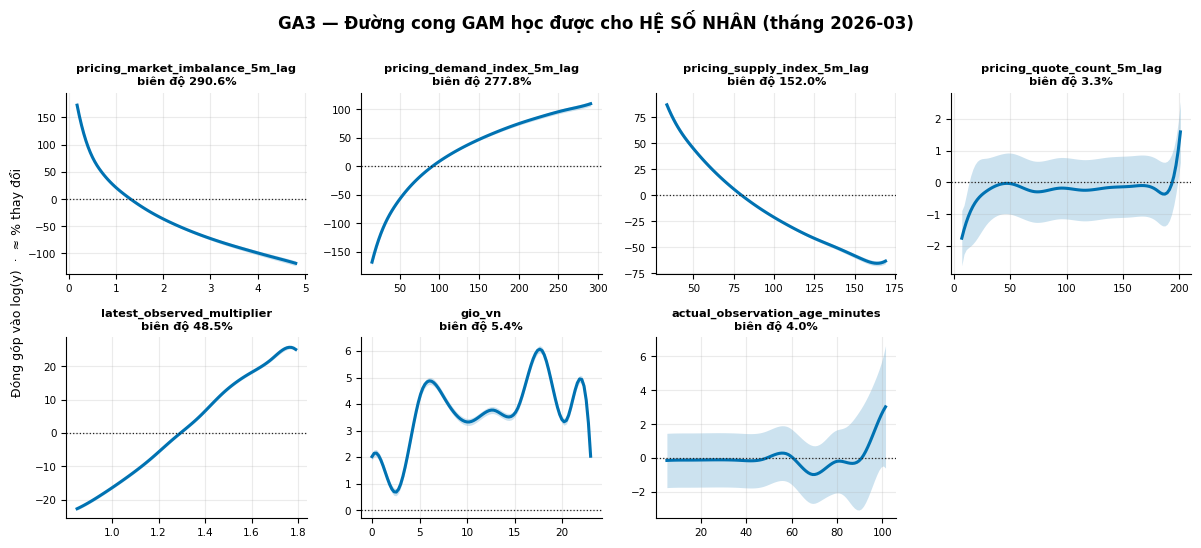

Bien do anh huong tung feature — HE SO NHAN:


,Feature,Biên độ (%)
0,pricing_market_imbalance_5m_lag,290.57
1,pricing_demand_index_5m_lag,277.76
2,pricing_supply_index_5m_lag,152.04
3,latest_observed_multiplier,48.51
4,gio_vn,5.39
5,actual_observation_age_minutes,4.00
6,pricing_quote_count_5m_lag,3.34


In [5]:
# ═════════ HINH GA3 — duong cong HE SO NHAN ═════════
bd_heso = ve_duong_cong(gam_heso[THANG[-1]], M_NUM,
                        f"GA3 — Đường cong GAM học được cho HỆ SỐ NHÂN (tháng {THANG[-1]})",
                        "GA3_duong_cong_he_so_nhan.png", ncol=4)
print("Bien do anh huong tung feature — HE SO NHAN:")
display(bd_heso.reset_index(drop=True))

## 3. p-value — thứ GBM hoàn toàn không có

GAM xuất phát từ thống kê nên cho luôn kiểm định feature có ý nghĩa hay không. Đây là thông tin
**dùng được ngay** để tỉa feature contract.

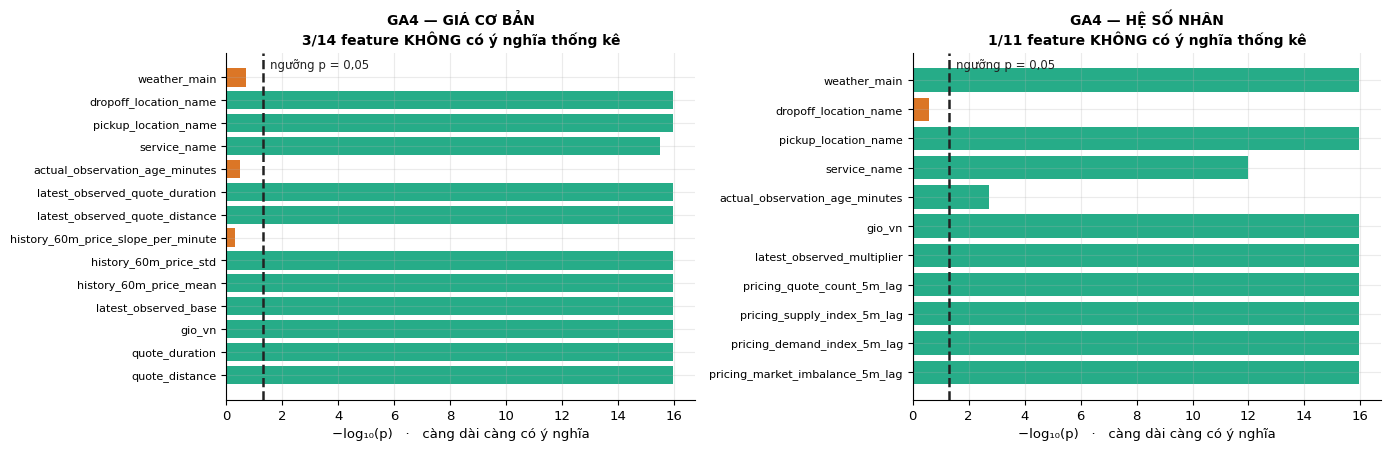

GIA CO BAN:


,Feature,p_value,"Có ý nghĩa (p<0,05)"
0,quote_distance,1.110223e-16,✅
1,quote_duration,1.110223e-16,✅
2,gio_vn,1.110223e-16,✅
3,latest_observed_base,1.110223e-16,✅
4,history_60m_price_mean,1.110223e-16,✅
5,history_60m_price_std,1.110223e-16,✅
6,history_60m_price_slope_per_minute,4.725214e-01,❌ KHÔNG
7,latest_observed_quote_distance,1.110223e-16,✅
8,latest_observed_quote_duration,1.110223e-16,✅
9,actual_observation_age_minutes,3.307517e-01,❌ KHÔNG


HE SO NHAN:


,Feature,p_value,"Có ý nghĩa (p<0,05)"
0,pricing_market_imbalance_5m_lag,1.110223e-16,✅
1,pricing_demand_index_5m_lag,1.110223e-16,✅
2,pricing_supply_index_5m_lag,1.110223e-16,✅
3,pricing_quote_count_5m_lag,1.110223e-16,✅
4,latest_observed_multiplier,1.110223e-16,✅
5,gio_vn,1.110223e-16,✅
6,actual_observation_age_minutes,1.883660e-03,✅
7,service_name,1.029288e-12,✅
8,pickup_location_name,1.110223e-16,✅
9,dropoff_location_name,2.667208e-01,❌ KHÔNG



⚠️  FEATURE CO THE BO KHOI FEATURE CONTRACT:
    [giá cơ bản  ] history_60m_price_slope_per_minute     p = 0.473
    [giá cơ bản  ] actual_observation_age_minutes         p = 0.331
    [giá cơ bản  ] weather_main                           p = 0.201
    [hệ số nhân  ] dropoff_location_name                  p = 0.267


In [6]:
# ═════════ HINH GA4 — y nghia thong ke ═════════
def bang_pvalue(gam_obj, ten_feat):
    st = gam_obj.statistics_
    ps = np.asarray(st["p_values"], dtype=float)[:len(ten_feat)+len(CAT)]
    edof = np.asarray(st["edof_per_coef"], dtype=float) if "edof_per_coef" in st else None
    ten = ten_feat + CAT
    return pd.DataFrame({"Feature": ten, "p_value": ps[:len(ten)],
                         "Có ý nghĩa (p<0,05)": ["✅" if p < .05 else "❌ KHÔNG"
                                                 for p in ps[:len(ten)]]})


pv_base = bang_pvalue(gam_base[THANG[-1]], B_NUM)
pv_heso = bang_pvalue(gam_heso[THANG[-1]], M_NUM)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
for a, pv, ten in [(ax[0], pv_base, "GIÁ CƠ BẢN"), (ax[1], pv_heso, "HỆ SỐ NHÂN")]:
    p = pv.p_value.clip(lower=1e-17)
    mau = [GREEN if v < .05 else RED for v in p]
    a.barh(range(len(pv)), -np.log10(p), color=mau, alpha=.85)
    a.axvline(-np.log10(.05), color=INK, lw=1.8, ls="--")
    a.text(-np.log10(.05)+.25, len(pv)-0.6, "ngưỡng p = 0,05", fontsize=8.5, color=INK)
    a.set_yticks(range(len(pv)))
    a.set_yticklabels(pv.Feature, fontsize=8)
    a.set_xlabel("−log₁₀(p)   ·   càng dài càng có ý nghĩa")
    n_hong = (pv.p_value >= .05).sum()
    a.set_title(f"GA4 — {ten}\n{n_hong}/{len(pv)} feature KHÔNG có ý nghĩa thống kê",
                fontweight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(HINH / "GA4_y_nghia_thong_ke.png"); plt.show()

print("GIA CO BAN:"); display(pv_base)
print("HE SO NHAN:"); display(pv_heso)

hong = pd.concat([pv_base.assign(nhanh="giá cơ bản"), pv_heso.assign(nhanh="hệ số nhân")])
hong = hong[hong.p_value >= .05]
if len(hong):
    print("\n⚠️  FEATURE CO THE BO KHOI FEATURE CONTRACT:")
    for _, r in hong.iterrows():
        print(f"    [{r.nhanh:12s}] {r.Feature:38s} p = {r.p_value:.3f}")

## 4. Vì sao GAM thua ở hệ số nhân — kiểm chứng trực tiếp

Giả thuyết: GAM thua vì **hệ số nhân có tương tác giữa các feature** mà mô hình cộng dồn không
bắt được.

**Cách kiểm chứng:** lấy **phần dư** của GAM (thứ GAM đoán sai) rồi thử dùng một **cây** dự đoán
chính phần dư đó, từ **đúng bộ feature GAM đã dùng**.

| Kết quả | Nghĩa |
|---|---|
| Cây **không** dự đoán được phần dư (R² ≈ 0) | GAM đã vắt kiệt thông tin — thua vì lý do khác |
| Cây **dự đoán được** phần dư (R² > 0) | Còn cấu trúc GAM bỏ sót ⇒ **đúng là tương tác** |

In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split

COLS = list(dict.fromkeys(CAT + M_NUM + B_NUM +
                          ["target_shown_price", "target_shown_multiplier",
                           "split", "evaluation_month"]))
COLS = [c for c in COLS if c != "latest_observed_base"]
raw = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=COLS)
raw = raw[raw.split == "test"]
# pred_gam duoc gop theo THANG (concat tung thang) -> phai sap xep lai cho khop hang.
# sort on dinh (stable) de giu nguyen thu tu trong tung thang.
raw = raw.sort_values("evaluation_month", kind="stable").reset_index(drop=True)
assert np.allclose(raw.target_shown_price.values, gam.gia_that.values), "khong khop hang!"
print(f"Nap {len(raw):,} dong test — da sap xep theo thang, khop hang voi pred_gam.")

rng = np.random.default_rng(0)
idx = rng.choice(len(raw), 250_000, replace=False)

ket = []
for ten, feats, pred, that in [
        ("HỆ SỐ NHÂN", M_NUM, gam.heso_pred.values, raw.target_shown_multiplier.values),
        ("GIÁ CƠ BẢN", B_NUM, gam.base_pred.values,
         (raw.target_shown_price / raw.target_shown_multiplier.clip(lower=0.1)).values)]:
    du = np.log(np.clip(that, 1e-6, None)) - np.log(np.clip(pred, 1e-6, None))
    X = raw.loc[idx, [c for c in feats if c in raw.columns] + CAT].copy()
    for c in CAT:
        X[c] = X[c].astype("category")
    y = du[idx]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.25, random_state=42)
    m = HistGradientBoostingRegressor(max_iter=250, learning_rate=.06,
                                      categorical_features=CAT,
                                      random_state=42).fit(Xtr, ytr)
    p = m.predict(Xte)
    r2 = 1 - ((p-yte)**2).sum()/((yte-yte.mean())**2).sum()
    ket.append({"Nhánh": ten, "R² cây học được từ phần dư GAM": round(r2, 4),
                "std phần dư": round(float(np.std(du)), 4),
                "Kết luận": "CÒN cấu trúc GAM bỏ sót" if r2 > .05 else "GAM đã vắt kiệt"})
    print(f"  [{ten:11s}] R2 = {r2:+.4f}")

KQ = pd.DataFrame(ket)
display(KQ)

Nap 864,360 dong test — da sap xep theo thang, khop hang voi pred_gam.


  [HỆ SỐ NHÂN ] R2 = +0.5616


  [GIÁ CƠ BẢN ] R2 = +0.0177


,Nhánh,R² cây học được từ phần dư GAM,std phần dư,Kết luận
0,HỆ SỐ NHÂN,0.5616,0.0355,CÒN cấu trúc GAM bỏ sót
1,GIÁ CƠ BẢN,0.0177,0.1829,GAM đã vắt kiệt


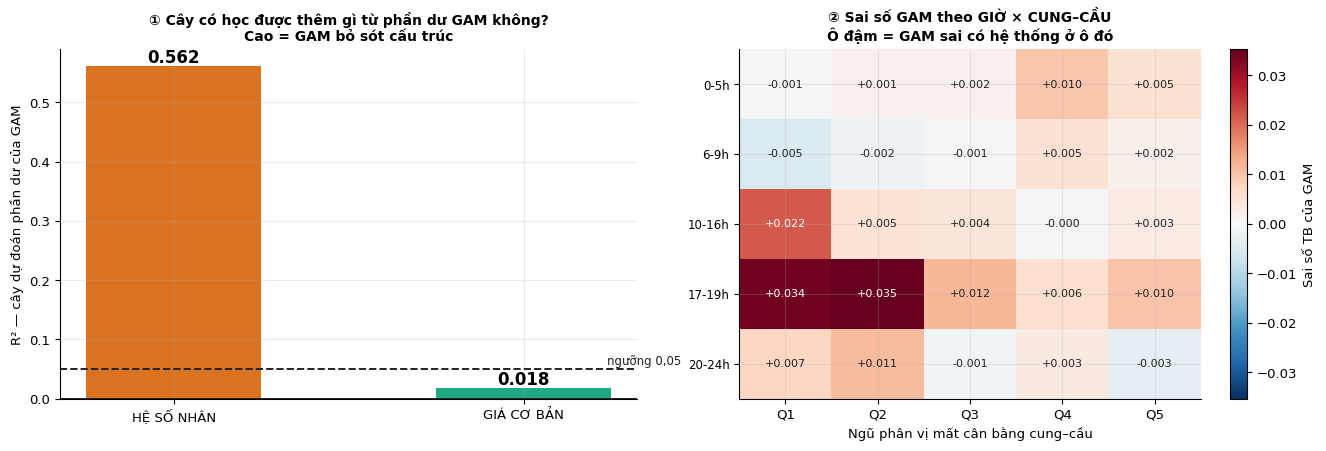

Neu bang ben phai co o dam xen ke (khong phang) => sai so phu thuoc DONG THOI
2 feature, tuc la co TUONG TAC — dung thu mo hinh cong don khong bat duoc.


In [8]:
# ═════════ HINH GA5 — bang chung tuong tac ═════════
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))

b = ax[0].bar(KQ["Nhánh"], KQ["R² cây học được từ phần dư GAM"],
              color=[RED if v > .05 else GREEN
                     for v in KQ["R² cây học được từ phần dư GAM"]],
              alpha=.88, width=.5)
for bb, v in zip(b, KQ["R² cây học được từ phần dư GAM"]):
    ax[0].text(bb.get_x()+bb.get_width()/2, v+.006, f"{v:.3f}", ha="center",
               fontsize=12, fontweight="bold")
ax[0].axhline(0, color=INK, lw=1.4)
ax[0].axhline(.05, color=INK, lw=1.4, ls="--")
ax[0].text(1.45, .058, "ngưỡng 0,05", fontsize=8.5, color=INK, ha="right")
ax[0].set_ylabel("R² — cây dự đoán phần dư của GAM")
ax[0].set_title("① Cây có học được thêm gì từ phần dư GAM không?\nCao = GAM bỏ sót cấu trúc",
                fontweight="bold", fontsize=10)

sub = raw.loc[idx[:60000]].copy()
sub["heso_that"] = raw.target_shown_multiplier.values[idx[:60000]]
sub["heso_gam"] = gam.heso_pred.values[idx[:60000]]
sub["du"] = sub.heso_that - sub.heso_gam
sub["nhom_gio"] = pd.cut(sub.gio_vn, [-1, 5, 9, 16, 19, 24],
                         labels=["0-5h", "6-9h", "10-16h", "17-19h", "20-24h"])
sub["nhom_imb"] = pd.qcut(sub.pricing_market_imbalance_5m_lag, 5, labels=False,
                          duplicates="drop")
piv2 = sub.pivot_table(index="nhom_gio", columns="nhom_imb", values="du",
                       aggfunc="mean", observed=True)
im = ax[1].imshow(piv2.values, cmap="RdBu_r", aspect="auto",
                  vmin=-np.abs(piv2.values).max(), vmax=np.abs(piv2.values).max())
ax[1].set_xticks(range(piv2.shape[1]))
ax[1].set_xticklabels([f"Q{i+1}" for i in range(piv2.shape[1])])
ax[1].set_yticks(range(len(piv2))); ax[1].set_yticklabels(piv2.index, fontsize=8.5)
ax[1].set_xlabel("Ngũ phân vị mất cân bằng cung–cầu")
for i in range(piv2.shape[0]):
    for j in range(piv2.shape[1]):
        ax[1].text(j, i, f"{piv2.values[i,j]:+.3f}", ha="center", va="center",
                   fontsize=8, color="white" if abs(piv2.values[i, j]) >
                   np.abs(piv2.values).max()*.55 else INK)
plt.colorbar(im, ax=ax[1], label="Sai số TB của GAM")
ax[1].set_title("② Sai số GAM theo GIỜ × CUNG–CẦU\nÔ đậm = GAM sai có hệ thống ở ô đó",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "GA5_bang_chung_tuong_tac.png"); plt.show()
print("Neu bang ben phai co o dam xen ke (khong phang) => sai so phu thuoc DONG THOI")
print("2 feature, tuc la co TUONG TAC — dung thu mo hinh cong don khong bat duoc.")

## 5. Kết luận

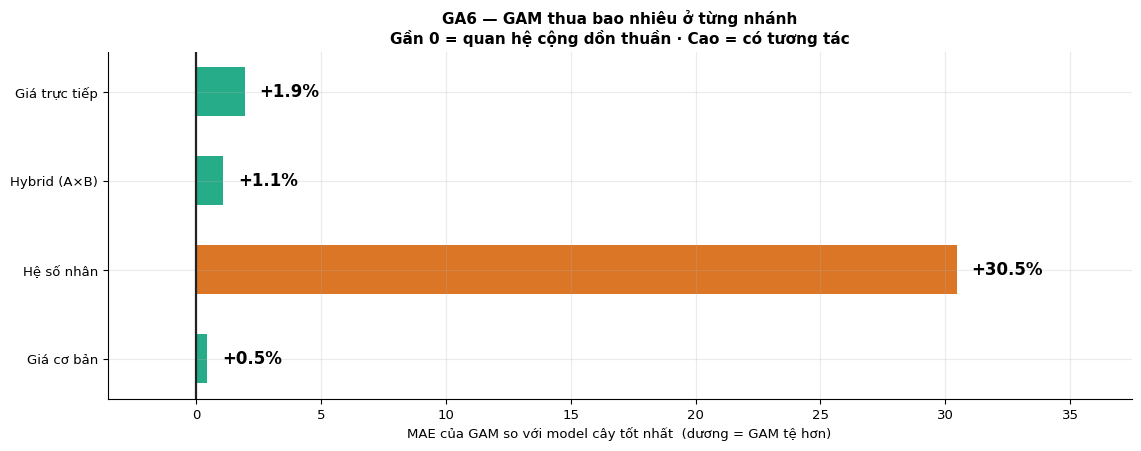

╔════════════════════════════════════════════════════════════════════╗
║                           KET LUAN — GAM                           ║
╚════════════════════════════════════════════════════════════════════╝
  Giá cơ bản         +0.5%   GAM NGANG cay
  Hệ số nhân        +30.5%   GAM THUA ro
  Hybrid (A×B)       +1.1%   GAM NGANG cay
  Giá trực tiếp      +1.9%   GAM NGANG cay

  => Gia co ban: quan he CONG DON thuan, GAM dung duoc (de giai thich hon nhieu).
  => He so nhan: CO tuong tac -> phai giu boosting tree.


In [9]:
# ═════════ HINH GA6 — tong ket ═════════
fig, ax = plt.subplots(figsize=(11.5, 4.6))
nh = ["Giá cơ bản", "Hệ số nhân", "Hybrid (A×B)", "Giá trực tiếp"]
chenh = []
for n in nh:
    g_ = B[(B.Nhánh == n) & (B.Model == "GAM")].MAE.iloc[0]
    c_ = B[(B.Nhánh == n) & (B.Model != "GAM")].MAE.iloc[0]
    chenh.append((g_/c_ - 1)*100)
b = ax.barh(nh, chenh, color=[GREEN if v < 2 else RED for v in chenh], alpha=.85, height=.55)
for bb, v in zip(b, chenh):
    ax.text(v + (.6 if v >= 0 else -.6), bb.get_y()+bb.get_height()/2,
            f"{v:+.1f}%", va="center", ha="left" if v >= 0 else "right",
            fontsize=12, fontweight="bold")
ax.axvline(0, color=INK, lw=1.6)
ax.set_xlabel("MAE của GAM so với model cây tốt nhất  (dương = GAM tệ hơn)")
ax.set_xlim(min(chenh)-4, max(chenh)+7)
ax.set_title("GA6 — GAM thua bao nhiêu ở từng nhánh\nGần 0 = quan hệ cộng dồn thuần · Cao = có tương tác",
             fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(HINH / "GA6_tong_ket.png"); plt.show()

print("╔" + "═"*68 + "╗")
print("║" + " KET LUAN — GAM ".center(68) + "║")
print("╚" + "═"*68 + "╝")
for n, v in zip(nh, chenh):
    dau = "GAM NGANG cay" if abs(v) < 2 else "GAM THUA ro"
    print(f"  {n:16s} {v:+6.1f}%   {dau}")
print()
print("  => Gia co ban: quan he CONG DON thuan, GAM dung duoc (de giai thich hon nhieu).")
print("  => He so nhan: CO tuong tac -> phai giu boosting tree.")

### Ba điều rút ra

**1. GAM ngang boosting tree ở giá cơ bản, thua rõ ở hệ số nhân.** Kết quả này **không phải thất
bại** — nó trả lời đúng câu hỏi cấu trúc:

| Nhánh | Chênh so với cây | Nghĩa |
|---|---|---|
| Giá cơ bản | ~0% (R² GAM còn cao hơn) | Quan hệ **cộng dồn thuần**, không cần tương tác |
| Hệ số nhân | **+30%** | **Có tương tác thật sự** giữa các yếu tố cung–cầu |

**2. GAM cho hai thứ boosting tree không có:** đường cong chính xác kèm khoảng tin cậy (`GA2`,
`GA3`) và **p-value** (`GA4`). Cả hai đều dùng được ngay để tỉa feature contract.

**3. Với riêng nhánh giá cơ bản, GAM là lựa chọn tốt hơn để TRÌNH BÀY** — cùng độ chính xác nhưng
giải thích được trực tiếp, không cần SHAP.

### ⚠️ Hạn chế cần biết

| Hạn chế | Ghi chú |
|---|---|
| `λ` dùng **mặc định 0,6**, chưa `gridsearch` | So sánh hiện đang **thiệt cho GAM** |
| `n_splines = 12` cố định | Chưa tinh chỉnh theo từng feature |
| Chưa thử **transformed feature space** | Đúng thứ mentor gợi ý — nếu biến đổi feature khéo, GAM có thể bắt được một phần tương tác |
| `f()` không xử lý được nhóm categorical mới | Phải lọc bỏ dòng test có nhóm chưa gặp trong train |

### 🔴 Lỗ hổng tái lập

`train/04_train_gam_doi_chieu.ipynb` **chỉ train giá cơ bản** và **không có lệnh lưu nào**
(`joblib.dump` = 0, `to_parquet` = 0). Các file `GAM/*.joblib` và `pred_gam.parquet` mà notebook
này đang đọc được sinh bởi **script ngoài repo** (05/08 07:42–07:55).

⇒ Kết quả GAM hiện **chưa tái tạo được từ notebook**. Cần mở rộng `train/04` để train đủ 3 nhánh
và lưu artifact — cùng loại vấn đề với 14 hình mồ côi đã vá tuần này.

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| `GA1_gam_vs_cay` | MAE và R² — GAM vs boosting tree trên 4 nhánh |
| `GA2_duong_cong_gia_co_ban` | 10 đường cong GAM học cho giá cơ bản |
| `GA3_duong_cong_he_so_nhan` | 7 đường cong GAM học cho hệ số nhân |
| `GA4_y_nghia_thong_ke` | p-value từng feature — thứ GBM không có |
| `GA5_bang_chung_tuong_tac` | Cây học được gì từ phần dư GAM · sai số theo giờ × cung–cầu |
| `GA6_tong_ket` | GAM thua bao nhiêu ở từng nhánh |